In [1]:
import os
import json
from datetime import datetime
import numpy as np
import pandas as pd
import tqdm as notebook_tqdm

import torch
import torch._dynamo

from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, f1_score

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
)

from peft import LoraConfig, PeftModel, get_peft_model

from data_collator_with_padding import DataCollatorWithGlobalPadding
from label_cluster_visualizer import LabelClusterVisualizer

In [2]:
torch.set_float32_matmul_precision("high")
torch._dynamo.config.capture_scalar_outputs = True

/home/logus/env/iscte/genai_p2/lib/python3.10/site-packages/torch/__init__.py:1617: UserWarning: Please use the new API settings to control TF32 behavior, such as torch.backends.cudnn.conv.fp32_precision = 'tf32' or torch.backends.cuda.matmul.fp32_precision = 'ieee'. Old settings, e.g, torch.backends.cuda.matmul.allow_tf32 = True, torch.backends.cudnn.allow_tf32 = True, allowTF32CuDNN() and allowTF32CuBLAS() will be deprecated after Pytorch 2.9. Please see https://pytorch.org/docs/main/notes/cuda.html#tensorfloat-32-tf32-on-ampere-and-later-devices (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:80.)
  _C._set_float32_matmul_precision(precision)


In [3]:
# Quiet the tokenizer fork warnings
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [4]:
MODEL_CONFIGS = {
    "longformer-base": {
        "name": "models/longformer-base-4096",
        "max_length": 4096,
        "batch_size": 64,
        "gradient_accumulation": 3,
        "needs_global_attention": False,
    },
    "longformer-large": {
        "name": "models/longformer-large-4096",
        "max_length": 4096,
        "batch_size": 8,
        "gradient_accumulation": 4,
        "needs_global_attention": False,
    },
    "led-base": {
        "name": "models/led-base-16384",
        "max_length": 8192,
        "batch_size": 8,
        "gradient_accumulation": 4,
        "needs_global_attention": True,
    },
    "led-large": {
        "name": "models/led-large-16384",
        "max_length": 8192,
        "batch_size": 4,
        "gradient_accumulation": 8,
        "needs_global_attention": True,
    },
}

# Selected model
SELECTED_MODEL = "longformer-base"  

In [5]:
SEED=42          # Ensure reproducibility
K=300            # K samples per each category

In [6]:
# Path to parquet file
PARQUET_FILE_PATH = "./data/arxiv_papers/train.parquet"

# Get selected configuration
config = MODEL_CONFIGS[SELECTED_MODEL]
model_name = config["name"]
max_length = config["max_length"]
batch_size = config["batch_size"]
gradient_accumulation_steps = config["gradient_accumulation"]
needs_global_attention = config["needs_global_attention"]

148 categories


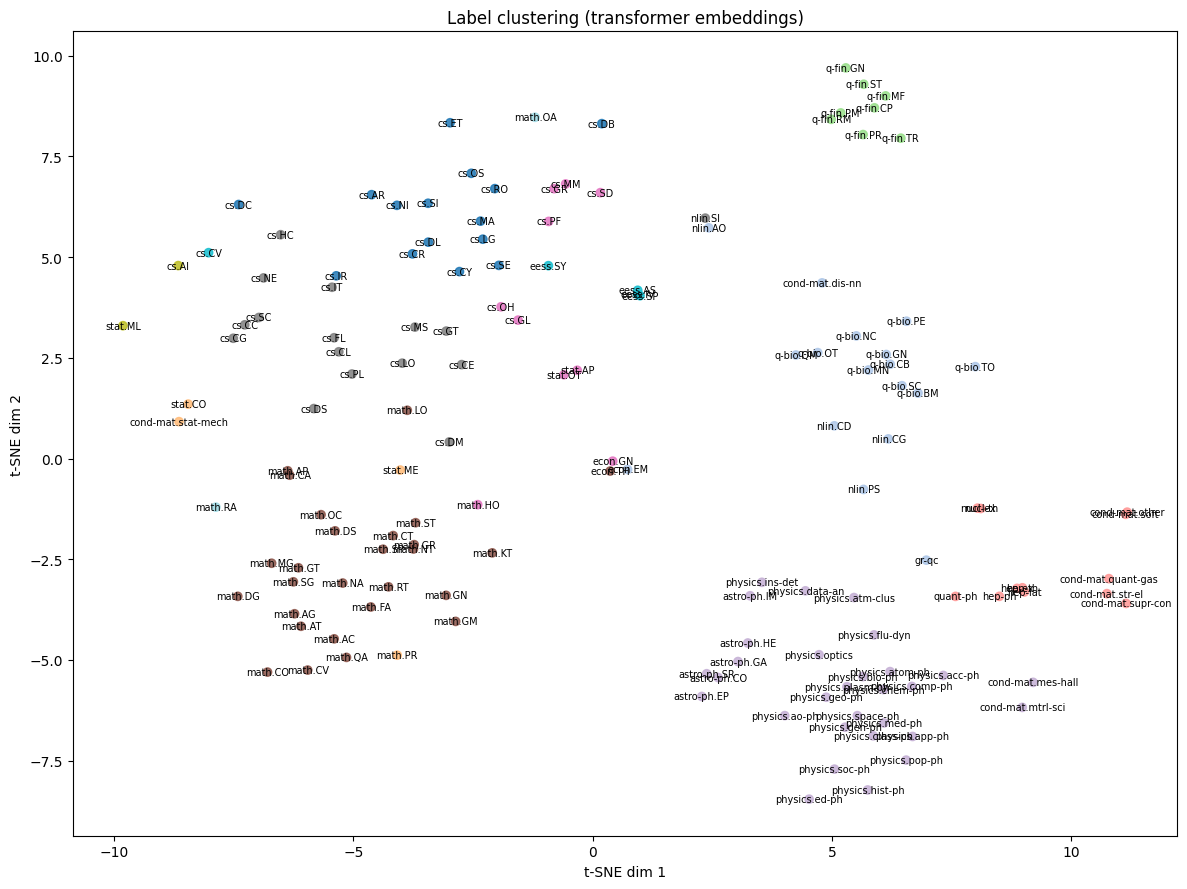


=== Cluster 0 ===
  cs.CY       Computers and Society (cs.CY)
  cs.CR       Cryptography and Security (cs.CR)
  cs.DB       Databases (cs.DB)
  cs.DL       Digital Libraries (cs.DL)
  cs.DC       Distributed, Parallel, and Cluster Computing (cs.DC)
  cs.ET       Emerging Technologies (cs.ET)
  cs.AR       Hardware Architecture (cs.AR)
  cs.IR       Information Retrieval (cs.IR)
  cs.LG       Machine Learning (cs.LG)
  cs.MA       Multiagent Systems (cs.MA)
  cs.NI       Networking and Internet Architecture (cs.NI)
  cs.OS       Operating Systems (cs.OS)
  cs.RO       Robotics (cs.RO)
  cs.SI       Social and Information Networks (cs.SI)
  cs.SE       Software Engineering (cs.SE)

=== Cluster 1 ===
  nlin.AO     Adaptation and Self-Organizing Systems (nlin.AO)
  q-bio.BM    Biomolecules (q-bio.BM)
  q-bio.CB    Cell Behavior (q-bio.CB)
  nlin.CG     Cellular Automata and Lattice Gases (nlin.CG)
  nlin.CD     Chaotic Dynamics (nlin.CD)
  cond-mat.dis-nn  Disordered Systems and Neural Ne

In [9]:
# Load the parquet file
df = pd.read_parquet(PARQUET_FILE_PATH)

# Build the categories list
categories = sorted(df["primary_subject"].dropna().unique().tolist())
print(len(categories), "categories")  # should be 148

# Create the visualizer
viz = LabelClusterVisualizer(
    model_name=model_name,
    n_clusters=12,
    max_length=64,
)

# Run the visualization
result = viz.visualize(categories)

# Print a text summary of each cluster
viz.print_cluster_summary()